# Machine learning for Regression

In [84]:
import pandas as pd
import numpy as np

In [85]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [86]:
!wget $data

--2026-05-20 17:13:17--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8003::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.4’

data.csv.4          100%[===================>]   1.41M  --.-KB/s    in 0.08s   

2026-05-20 17:13:17 (16.7 MB/s) - ‘data.csv.4’ saved [1475504/1475504]



In [87]:
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [88]:
# changing the column names to lower case and replacing spaces with underscores
df.columns = df.columns.str.replace(' ', '_').str.lower()

df.dtypes[df.dtypes == 'str']


make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [89]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [90]:
for col in strings:
    df[col] = df[col].str.replace(' ', '_').str.lower()

In [91]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# Data Summary 

In [235]:
summary = []
for col in df.columns:
    values = df[col].dropna().unique()[:5]

    summary.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "unique_count": df[col].nunique(),
        "null_values": df[col].isnull().sum(),
        "examples": ", ".join(map(str, values))
    })

summary_df = pd.DataFrame(summary)

summary_df

,column,dtype,unique_count,null_values,examples
0,make,str,48,0,"bmw, audi, fiat, mercedes-benz, chrysler"
1,model,str,914,0,"1_series_m, 1_series, 100, 124_spider, 190-class"
2,year,int64,28,0,"2011, 2012, 2013, 1992, 1993"
3,engine_fuel_type,str,10,3,"premium_unleaded_(required), regular_unleaded,..."
4,engine_hp,float64,356,69,"335.0, 300.0, 230.0, 320.0, 172.0"
5,engine_cylinders,float64,9,30,"6.0, 4.0, 5.0, 8.0, 12.0"
6,transmission_type,str,5,0,"manual, automatic, automated_manual, direct_dr..."
7,driven_wheels,str,4,0,"rear_wheel_drive, front_wheel_drive, all_wheel..."
8,number_of_doors,float64,3,6,"2.0, 4.0, 3.0"
9,market_category,str,71,3742,"factory_tuner,luxury,high-performance, luxury,..."


# Price Distribution

In [93]:
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline 

<Axes: xlabel='msrp', ylabel='Count'>

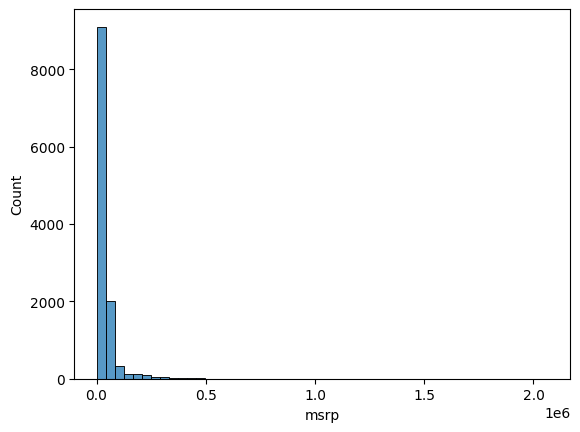

In [94]:
sns.histplot(df.msrp, bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

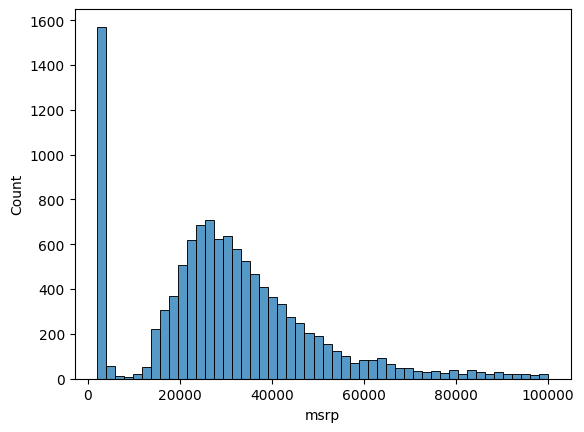

In [95]:
sns.histplot(df.msrp[df.msrp < 100000], bins = 50)

## Long-Tail Distribution Summary

A **long-tail distribution** means most values are concentrated in a small range, while a few values are extremely large.

In the `msrp` price distribution, most cars have low or normal prices, but a small number of cars are very expensive. This creates a long tail on the right side of the histogram, also called a **right-skewed distribution**.

## Why It Matters in Machine Learning

Long-tail distributions can cause problems because:

- The model learns common low-price examples better than rare expensive examples.
- Very large values can strongly affect the loss function.
- Metrics like RMSE can be misleading because they are sensitive to extreme values.
- The model may perform poorly on rare high-value cases.

## Common Solution

A standard solution is to apply a **log transformation** to the target variable to make it a normal distribution:

```python
y = np.log1p(x)

<Axes: xlabel='msrp', ylabel='Count'>

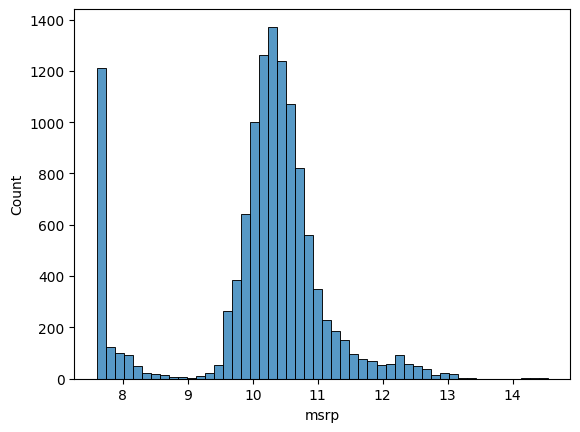

In [236]:
price_logs = np.log1p(df.msrp)
sns.histplot(price_logs, bins = 50)

## Validation Framework: 60/20/20 Split

A validation framework helps us evaluate machine learning models fairly.

The dataset is usually split into:

- **60% Training Set**: used to train the model.
- **20% Validation Set**: used to compare models and tune parameters.
- **20% Test Set**: used only at the end for the final evaluation.

The training set teaches the model patterns.

The validation set helps us choose the best model and avoid overfitting.

The test set gives a final estimate of how the model performs on new, unseen data.

We should not use the test set during model development, because it must remain unseen for a fair final check.

In [237]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [238]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [239]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [240]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7146,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7147,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65055
7148,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,67220


In [241]:
idx = np.arange(n)

In [242]:
np.random.seed(2)
np.random.shuffle(idx)

In [243]:
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

In [244]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [245]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [246]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [247]:
# delete the msrp column to avoid using it 
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# Linear Regression

In [248]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [249]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]
    

In [250]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [251]:
linear_regression(xi)

12.312

In [252]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [253]:
def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res


def linear_regression(xi):
    return w0 + dot(xi, w)

In [117]:
linear_regression(xi)

12.312000000000001

# Linear regression vector form

In [118]:

w_new = [w0] + w

def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res


def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

# Training the Model 

# Normal Equation vs Gradient Descent

Both methods are used to find the best weights for linear regression.

The **normal equation** finds the weights directly using:

`w = (XᵀX)⁻¹ Xᵀy`

It is a one-step mathematical solution. It does not need a learning rate or repeated updates, but it can become slow when the dataset has many features because it requires matrix inversion.

**Gradient descent** finds the weights step by step. It starts with initial weights, calculates the error, and updates the weights many times until the model improves.

Main difference:

- Normal equation: solves directly in one step.
- Gradient descent: learns gradually through many iterations.

Normal equation is simple and useful for smaller datasets. Gradient descent is more flexible and better for large datasets or complex models like neural networks.

In [34]:
def train_linear_regression(X, y):
    pass

In [119]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [120]:
ones = np.ones(X.shape[0])
ones 

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [121]:
# X = np.column_stack([ones, X])
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [76]:
# we want to calculate `w = (XᵀX)⁻¹ Xᵀy`
# first the invers of the Gram Matrix (XᵀX)⁻¹
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)

In [77]:
XTX_inv.dot(XTX).round(1)

array([[ 1., -0., -0.,  0.],
       [ 0.,  1., -0.,  0.],
       [ 0.,  0.,  1., -0.],
       [ 0.,  0., -0.,  1.]])

In [78]:
# now the full formula `(XᵀX)⁻¹ Xᵀy`
w_full = XTX_inv.dot(X.T).dot(y)

In [79]:
w0 = w_full[0]
w = w_full[1:]

In [80]:
w0, w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [126]:

y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]
X, y

(array([[ 148,   24, 1385],
        [ 132,   25, 2031],
        [ 453,   11,   86],
        [ 158,   24,  185],
        [ 172,   25,  201],
        [ 413,   11,   86],
        [  38,   54,  185],
        [ 142,   25,  431],
        [ 453,   31,   86]]),
 [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000])

In [127]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [128]:
train_linear_regression(X, y)

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [83]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


# Car price baseline model 

In [254]:
df_train.columns[df_train.dtypes != "str"]

Index(['year', 'engine_hp', 'engine_cylinders', 'number_of_doors',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [255]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [256]:
X_train = df_train[base].values
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [257]:
df_train[base].isnull().sum()
# we need to fill in the null values with 0 in order for the model to run and ignore the null values 
X_train = df_train[base].fillna(0).values

In [258]:
np.isnan(X_train).sum()

np.int64(0)

In [259]:
w0, w = train_linear_regression(X_train, y_train)

In [260]:
w0, w

(np.float64(7.927257388069986),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [261]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

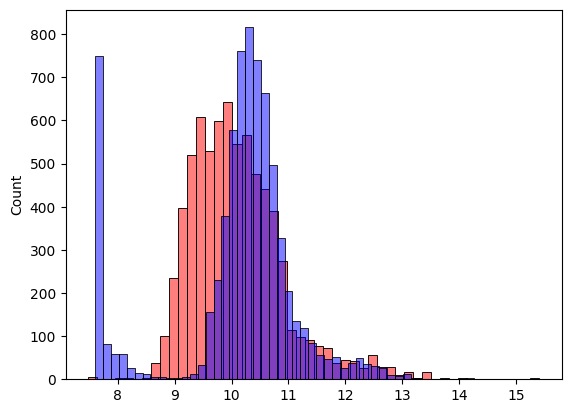

In [262]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue',alpha=0.5, bins=50)

## Comparing Predictions with Actual Values

The plot compares the distribution of the model predictions with the actual training target values.

- **Blue** represents the actual values: `y_train`
- **Red** represents the predicted values: `y_pred`

From the graph, the predicted values are shifted slightly to the left compared to the actual values. This means the model is often predicting smaller values than the real values.

The peaks of the two distributions are not fully aligned. The actual values peak around a higher range, while the predictions peak slightly lower. This suggests that the model is underestimating the target in many cases.

## What This Means

The model has learned the general shape of the target distribution, but it is not perfectly matching the real data.

Possible reasons:

- The model is too simple and cannot capture all patterns in the data.
- Important features may be missing.
- Some categorical variables may not be included yet.
- The model may be underfitting.
- Outliers or long-tail values may be affecting the training.

## Summary

The prediction distribution is close to the actual distribution, but it is shifted to the left. This indicates that the model tends to predict lower values than expected. To improve the model, we may need better features, categorical encoding, regularization tuning, or a more flexible model.

# Root Mean Squared Error (RMSE)

RMSE is a regression metric used to measure how far the model's predictions are from the actual values.

The formula is:

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$
Where:

- $n$ = number of observations
- $y_i$ = actual value for observation $i$
- $\hat{y}_i$ = predicted value for observation $i$
- $y_i - \hat{y}_i$ = prediction error
- $(y_i - \hat{y}_i)^2$ = squared error

## Rule

The model with the **smaller RMSE** is better:
Steps:

1. Calculate the error between actual and predicted values.
2. Square the errors.
3. Take the average of the squared errors.
4. Take the square root.

RMSE is useful because it gives one number that tells us how large the model's prediction errors are.

The main rule is:

**Lower RMSE is better.**

A lower RMSE means the model's predictions are closer to the real values.

RMSE also punishes large errors more because the errors are squared. This makes RMSE sensitive to outliers.

In the car price project, we usually apply log transformation to the target:

`y = np.log1p(df.msrp)`

So RMSE is calculated on the log-price scale, not directly in dollars.

We use RMSE mainly to compare models on the validation set. The model with the lower validation RMSE is usually the better model.

In [263]:
def rmse(y, y_pred):
    sq_error = (y - y_pred) ** 2 
    msq_error = sq_error.mean()
    return np.sqrt(msq_error)
    

In [264]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

# Validating the Model 
 now, we will try to minimize the RMSE 0.75 we found earlier

In [265]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X
    

In [266]:
X_trian = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

# now we will use the validation 
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.761653099130156)

# Simple feature engineering 
### adding the car age as a new feature 

In [267]:
def prepare_X(df):
    df = df.copy()
    df['age'] = df.year.max() - df.year
    features = base + ['age']

    df_num = df[features].fillna(0)
    X = df_num.values
    return X

In [268]:
X_train = prepare_X(df_train)
df_train.columns[df_train.dtypes != "str"]

Index(['year', 'engine_hp', 'engine_cylinders', 'number_of_doors',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [269]:
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5172055461058299)

<Axes: ylabel='Count'>

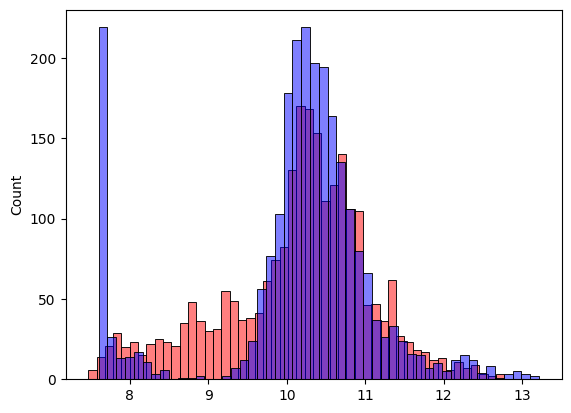

In [270]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue',alpha=0.5, bins=50)

## Categorical variables
Categorical variables are columns that contain labels or groups instead of continuous numbers.

Examples:

- `make`
- `model`
- `transmission_type`
- `vehicle_style`
- `fuel_type`

Machine learning models need numerical input, so we convert categorical values into numbers.

## One-Hot Encoding

One common method is **one-hot encoding**.

It creates a new column for each category and uses:

- `1` if the row belongs to that category
- `0` if it does not

Example:

`transmission_type = AUTOMATIC`

becomes:

`transmission_type_AUTOMATIC = 1`  
`transmission_type_MANUAL = 0`

This avoids creating a fake order between categories.

## Why Not Use 1, 2, 3?

If we encode categories like this:

`AUTOMATIC = 1`  
`MANUAL = 2`  
`AUTOMATED_MANUAL = 3`

the model may think there is an order between them.

But these categories are just labels, not ranked values.

## Other Encoding Methods

Other ways to encode categorical variables include:

- **Label encoding**: gives each category a number.
- **Ordinal encoding**: used when categories have a real order.
- **Frequency encoding**: replaces categories with their frequency.
- **Target encoding**: replaces categories with the average target value for that category.

For linear regression, one-hot encoding is usually the safest and most common approach.

In [217]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [214]:
#for v in [2, 3, 4]:
  #  df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

In [271]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    df['age'] = df.year.max() - df.year
    features.append('age')
    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    df_num = df[features].fillna(0)
    X = df_num.values
    return X 
        

In [272]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [273]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.515799564150169)

#### The model did not improve a lot after adding the doors feature

In [275]:
makes = list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [278]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    df['age'] = df.year.max() - df.year
    features.append('age')
    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    for c in makes:
        df['make_%s' % c] = (df.make == c).astype('int')
        features.append('make_%s' % c)
    df_num = df[features].fillna(0)
    X = df_num.values
    return X 

In [279]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849556795)

In [280]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [281]:
categorical

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'model': ['silverado_1500', 'tundra', 'f-150', 'sierra_1500', 'tacoma'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'hatchback',
  'luxury,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [282]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [283]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(53.70370772576197)

In [285]:
w0, w

(np.float64(120883643437600.25),
 array([ 1.97815705e-01,  3.59996839e+00,  1.77430262e-01,  2.54401440e+00,
        -3.91209144e-04,  1.31841741e+00, -1.87629844e+03, -1.87912990e+03,
        -1.87135179e+03, -3.16525752e+00,  8.11185787e-01,  8.76573747e+00,
        -7.26348843e+00, -5.87324602e+00, -3.43160292e+01, -2.49085861e+01,
        -4.50399871e+01, -2.85752551e+01,  9.63377197e+00,  3.79004788e+02,
         3.54982604e+02,  3.73756735e+02,  4.23480737e+02,  3.19067990e+02,
        -1.20883643e+14, -1.20883643e+14, -1.20883643e+14, -1.20883643e+14,
        -2.07609706e-01, -6.37629899e-01, -4.67620395e-01,  2.49283098e+01,
         4.01327473e+00, -2.32017237e+01, -2.26915593e+01, -5.85429953e+00,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

# Regularization
## Why the Model Got Worse After Adding Categorical Features

After adding more categorical features, the model became unstable and the RMSE became very large.

The issue comes from the normal equation:

$$
w = (X^T X)^{-1}X^T y
$$

The problematic part is:

$$
(X^T X)^{-1}
$$

For this inverse to exist, the columns of `X` must be linearly independent.

When we convert categorical variables into 0/1 columns, we may accidentally create columns that can be calculated from other columns.

For example, if `vehicle_size` has three categories:

$$
compact + midsize + large = 1
$$

But the model also has an intercept column, which is a column of ones.

So the category columns can recreate the intercept column:

$$
intercept = compact + midsize + large
$$

This means the columns are linearly dependent.

Because of this, `X^T X` becomes singular or nearly singular. When we try to invert it, the model produces extremely large unstable weights.

That is why the model got worse even after adding more features.

The problem is not simply that we added more features. The problem is that some of the new feature columns repeated information already contained in other columns.

## Standard Solutions

1. Use regularization.

   Regularization changes the equation to:

   $$
   w = (X^T X + \alpha I)^{-1}X^T y
   $$

   The added term:

   $$
   \alpha I
   $$

   helps make the matrix easier to invert and prevents the weights from becoming extremely large.

## Key Idea

Adding categorical variables can improve the model, but it can also create repeated or dependent columns.

When columns are dependent, the matrix inverse becomes unstable, the weights become extremely large, and the predictions become bad.

Regularization helps fix this problem.

In [296]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


In [303]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4608208286551885)

# Tuning the Model 

In [308]:
results = []

for r in [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    results.append({
        "r": r,
        "w0": w0,
        "rmse": score
    })

results_df = pd.DataFrame(results)
results_df

,r,w0,rmse
0,0.00001,8.377537,0.460815
1,0.00010,7.139523,0.460815
2,0.00100,7.130903,0.460816
3,0.01000,7.118382,0.460821
4,0.10000,7.000232,0.460874
5,1.00000,6.250748,0.461581


In [310]:
r = 0.001 
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score = rmse(y_val, y_pred)
score

np.float64(0.4608158585540023)

# Using the mode

## now we will use the model on both the training data set and the validation data set then see how it perfomes on the testing data set

In [323]:
df_full_train = pd.concat([df_train, df_val])
df_full_train.reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])


In [324]:
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(9532,))

In [331]:
y_test

array([ 7.60140233,  8.07464908, 10.34563811, ..., 10.27852782,
       10.00789261, 10.40414162], shape=(2382,))

In [333]:
X_full_train = np.concatenate([X_train, X_val])
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=r)
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.4600753970082232)